In [1]:
#Data + Labels + Feature Table
%pip install earthengine-api
%pip install geemap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Authenticate and Initialize Earth Engine
import ee
ee.Authenticate()
ee.Initialize()

In [3]:
#Define Munich Region of Interest (ROI)
munich_roi = ee.Geometry.Rectangle([11.360, 48.061, 11.722, 48.248])        #Longitude and Latitude bounds for Munich

#Load Sentinel-2 Image Collection and Filter by Date and ROI
sentinel2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(munich_roi).filterDate('2023-01-01', '2023-12-31').filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))  #Filter for low cloud cover

#Median Composite to Reduce Noise
sentinel2_median = sentinel2.median().clip(munich_roi)

#Select 10 m bands (B2, B3, B4, B8) for feature extraction
sentinel2_features = sentinel2_median.select(['B2', 'B3', 'B4', 'B8'])  #Blue, Green, Red, NIR bands for vegetation analysis

#Compute NDVI (Normalized Difference Vegetation Index) as an additional feature
ndvi = sentinel2_features.normalizedDifference(['B8', 'B4']).rename('NDVI')  #NDVI = (NIR - Red) / (NIR + Red)

#Compute NDBI (Normalized Difference Built-up Index) as an additional feature
ndbi = sentinel2_median.normalizedDifference(['B11', 'B8']).rename('NDBI')  #NDBI = (SWIR - NIR) / (SWIR + NIR)

#Combine all features into a single image
feature_image = sentinel2_features.addBands([ndvi, ndbi])

In [4]:
print("Number of images:", sentinel2.size().getInfo()) #A total of 251 Sentinel-2 scenes were used to generate a cloud-reduced median composite for 2023
print(feature_image.bandNames().getInfo())

Number of images: 52
['B2', 'B3', 'B4', 'B8', 'NDVI', 'NDBI']


In [5]:
# Convert ROI to GeoJSON format explicitly
region_geojson = munich_roi.getInfo()['coordinates']

feature_image = feature_image.toFloat()  #Convert to float for better precision in exported data

task = ee.batch.Export.image.toDrive(
    image=feature_image,
    description='Munich_Sentinel2_Features_2023',
    folder='EarthEngineExports',
    fileNamePrefix='munich_s2_2023_features',
    region=region_geojson,
    scale=20,
    crs='EPSG:32632',
    maxPixels=1e13
)

task.start()
print(task.status())

{'state': 'READY', 'description': 'Munich_Sentinel2_Features_2023', 'priority': 100, 'creation_timestamp_ms': 1771372900867, 'update_timestamp_ms': 1771372900867, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'LPXMYBD7AO5ZNI5ASJRPYEW2', 'name': 'projects/319422420910/operations/LPXMYBD7AO5ZNI5ASJRPYEW2'}


In [6]:
print(task.status())

{'state': 'READY', 'description': 'Munich_Sentinel2_Features_2023', 'priority': 100, 'creation_timestamp_ms': 1771372900867, 'update_timestamp_ms': 1771372900867, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'LPXMYBD7AO5ZNI5ASJRPYEW2', 'name': 'projects/319422420910/operations/LPXMYBD7AO5ZNI5ASJRPYEW2'}


In [7]:
import rasterio
import geopandas
import numpy as np
import pandas


In [8]:
#Create a 100m grid and extract mean feature values for each grid cell
raster_path = 'munich_s2_2023_features.tif'
src = rasterio.open(raster_path)
print("CRS:", src.crs)
print("Resolution:", src.res)
print("width:", src.width)
print("height:", src.height)
print("Number of bands:", src.count)

CRS: EPSG:32632
Resolution: (20.0, 20.0)
width: 1382
height: 1085
Number of bands: 6


In [9]:
#Create Aggregated Feature Table
data = src.read()  #Read all bands into a numpy array
bands, height, width = data.shape
print("Data shape (bands, height, width):", data.shape)

#Define grid size
grid_size = 5 #5x5 pixel grid corresponds to 100m x 100m at 20m resolution
grid_rows = height // grid_size
grid_cols = width // grid_size
print("Grid size (rows, cols):", (grid_rows, grid_cols))

#Initialize list to store aggregated features
aggregated_data = []
grid_positions = []  #To store grid cell center coordinates

#Loop through each grid cell and compute mean feature values
for i in range(grid_rows):
    for j in range(grid_cols):
        #Define grid cell boundaries
        row_start = i * grid_size
        row_end = row_start + grid_size
        col_start = j * grid_size
        col_end = col_start + grid_size
        
        #Extract pixel values for the current grid cell
        cell_data = data[:, row_start:row_end, col_start:col_end]

        #Ignore cells with no data (all values are NaN)
        if np.isnan(cell_data).all():
            continue
        
        #Compute mean feature values for the grid cell
        mean_features = np.nanmean(cell_data, axis=(1, 2))  #Mean across spatial dimensions

        #Skip features with NaN values
        if np.isnan(mean_features).any():
            continue
        aggregated_data.append(mean_features)
        grid_positions.append((i, j))  #Store grid cell position for later use
aggregated_data = np.array(aggregated_data)
print("Aggregated data shape (samples, features):", aggregated_data.shape)

Data shape (bands, height, width): (6, 1085, 1382)
Grid size (rows, cols): (217, 276)
Aggregated data shape (samples, features): (56488, 6)


In [10]:
#Convert to DataFrame for easier analysis
feature_names = src.descriptions if src.descriptions else [f'Band_{i+1}' for i in range(bands)]
df = pandas.DataFrame(aggregated_data, columns=feature_names)
print(df.head())

           B2           B3          B4           B8      NDVI      NDBI
0  348.500000   557.000000  522.500000  3702.500000  0.752663 -0.276284
1  343.000000   555.400024  512.900024  3220.699951  0.728670 -0.295513
2  258.299988   457.799988  340.500000  2977.300049  0.800754 -0.293213
3  415.000000   672.599976  581.500000  2953.000000  0.680461 -0.217349
4  610.900024  1052.699951  790.900024  3273.699951  0.610513 -0.200174


In [11]:
#Create Brownfield Candidate Label
df['brownfield_candidate'] = 0  #Initialize all labels to 0 (non-vegetated)
df.loc[(df['NDVI'] > 0.4) & (df['NDBI'] > 0) & (df['NDVI'] < 0.8), 'brownfield_candidate'] = 1  #Label as 1 (vegetated) if NDVI > 0.4 and NDBI > 0 and NDVI < 0.8
print("Brownfield candidate distribution:\n", df['brownfield_candidate'].value_counts())

Brownfield candidate distribution:
 brownfield_candidate
0    54938
1     1550
Name: count, dtype: int64


In [12]:
# Importing necessary libraries
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [13]:
#Train-test split
X = df[['B2', 'B3', 'B4', 'B8', 'NDVI', 'NDBI']]  #Features (excluding label and original bands)
y = df['brownfield_candidate']  #Labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 45190
Testing samples: 11298


In [14]:
#Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

#Evaluate model performance
y_pred = rf_classifier.predict(X_test)
y_full = rf_classifier.predict(X)  #Predict on the entire dataset to analyze feature importance across all samples
pred_map = np.full((grid_rows, grid_cols), np.nan)

index = 0

for idx, (i, j) in enumerate(grid_positions):
    pred_map[i, j] = y_full[idx]

In [15]:
#Checking accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10988
           1       1.00      1.00      1.00       310

    accuracy                           1.00     11298
   macro avg       1.00      1.00      1.00     11298
weighted avg       1.00      1.00      1.00     11298

Confusion Matrix:
 [[10988     0]
 [    0   310]]


In [16]:
from sklearn.dummy import DummyClassifier
dummy_classifier = DummyClassifier(strategy='most_frequent')
dummy_classifier.fit(X_train, y_train)
y_dummy_pred = dummy_classifier.predict(X_test)
dummy_accuracy = accuracy_score(y_test, y_dummy_pred)
print("Dummy Classifier Accuracy:", dummy_accuracy)

Dummy Classifier Accuracy: 0.9725615153124447


In [17]:
from sklearn.metrics import roc_curve, auc
y_prob = rf_classifier.predict_proba(X_test)[:, 1]  #Probability of positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

ROC AUC: 1.0


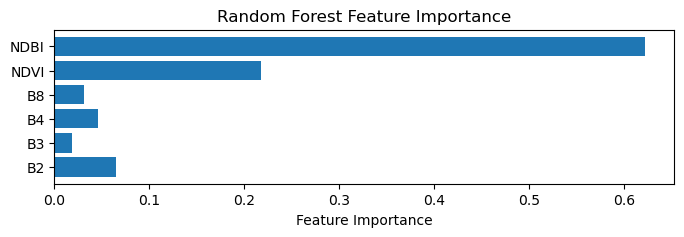

In [18]:
#Feature importance analysis
import matplotlib.pyplot as plt
feature_importances = rf_classifier.feature_importances_
feature_names = X.columns
plt.figure(figsize=(8, 2))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

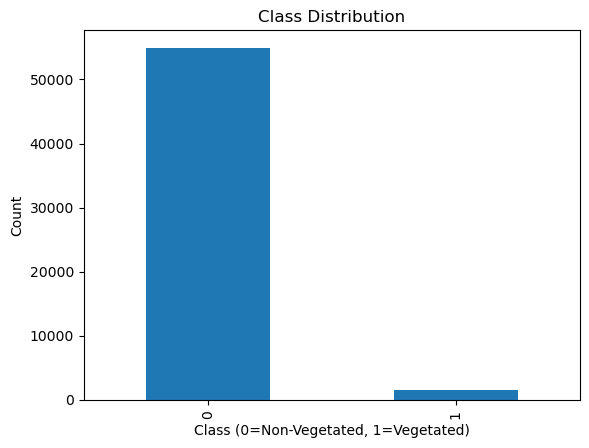

In [19]:
#Class distribution analysis
df['brownfield_candidate'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0=Non-Vegetated, 1=Vegetated)")
plt.ylabel("Count")
plt.show()

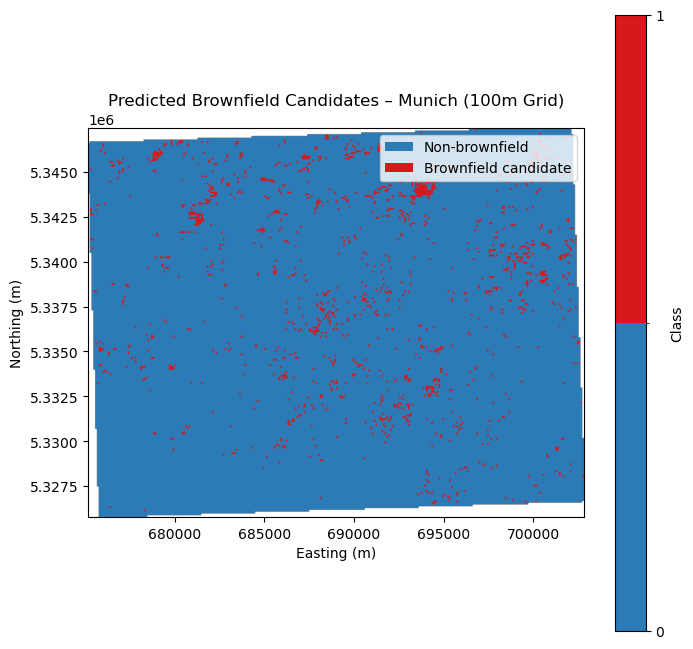

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Get spatial transform from raster
transform = src.transform

# Define discrete colors
cmap = mcolors.ListedColormap(['#2c7bb6', '#d7191c'])  # Blue = non-brownfield, Red = brownfield
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8,8))
plt.imshow(pred_map,
           cmap=cmap,
           norm=norm,
           extent=[
               transform[2],
               transform[2] + transform[0]*src.width,
               transform[5] + transform[4]*src.height,
               transform[5]
           ])


legend_elements = [
    Patch(facecolor='#2c7bb6', label='Non-brownfield'),
    Patch(facecolor='#d7191c', label='Brownfield candidate')
]

plt.legend(handles=legend_elements, loc='upper right')
plt.title("Predicted Brownfield Candidates – Munich (100m Grid)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.colorbar(ticks=[0,1], label="Class")
plt.show()

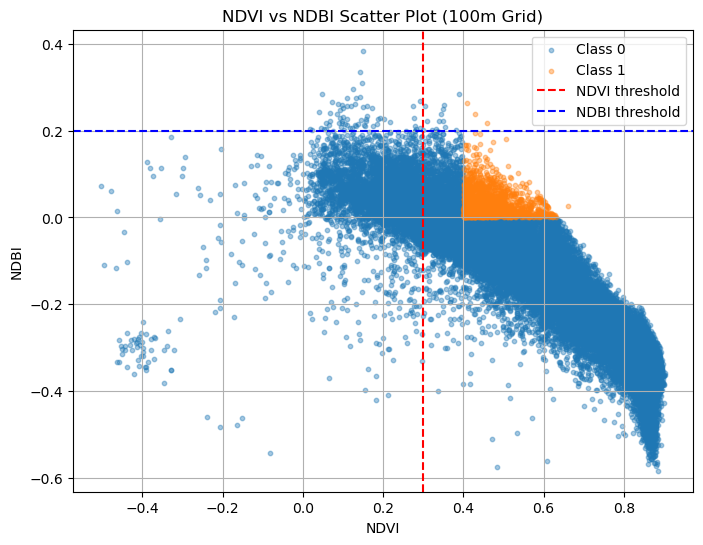

In [21]:
#Scatter plot of NDVI vs NDBI colored by brownfield candidate class

plt.figure(figsize=(8,6))

# Scatter plot with different colors per class
for label_value in df['brownfield_candidate'].unique():
    subset = df[df['brownfield_candidate'] == label_value]
    plt.scatter(
        subset['NDVI'],
        subset['NDBI'],
        label=f"Class {label_value}",
        alpha=0.4,
        s=10
    )

plt.axvline(0.3, color='red', linestyle='--', label='NDVI threshold')
plt.axhline(0.2, color='blue', linestyle='--', label='NDBI threshold')

plt.xlabel("NDVI")
plt.ylabel("NDBI")
plt.title("NDVI vs NDBI Scatter Plot (100m Grid)")
plt.legend()
plt.grid(True)
plt.show()
